# 10 - Histogram Equalization and CLAHE

Global histogram equalization uses the cumulative distribution \(c(k)=\sum_{j=0}^{k}p(j)\) and the mapping \(s(k)=\operatorname{round}((L-1)c(k))\). CLAHE applies bounded local mappings to reduce excessive amplification.

In [10]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


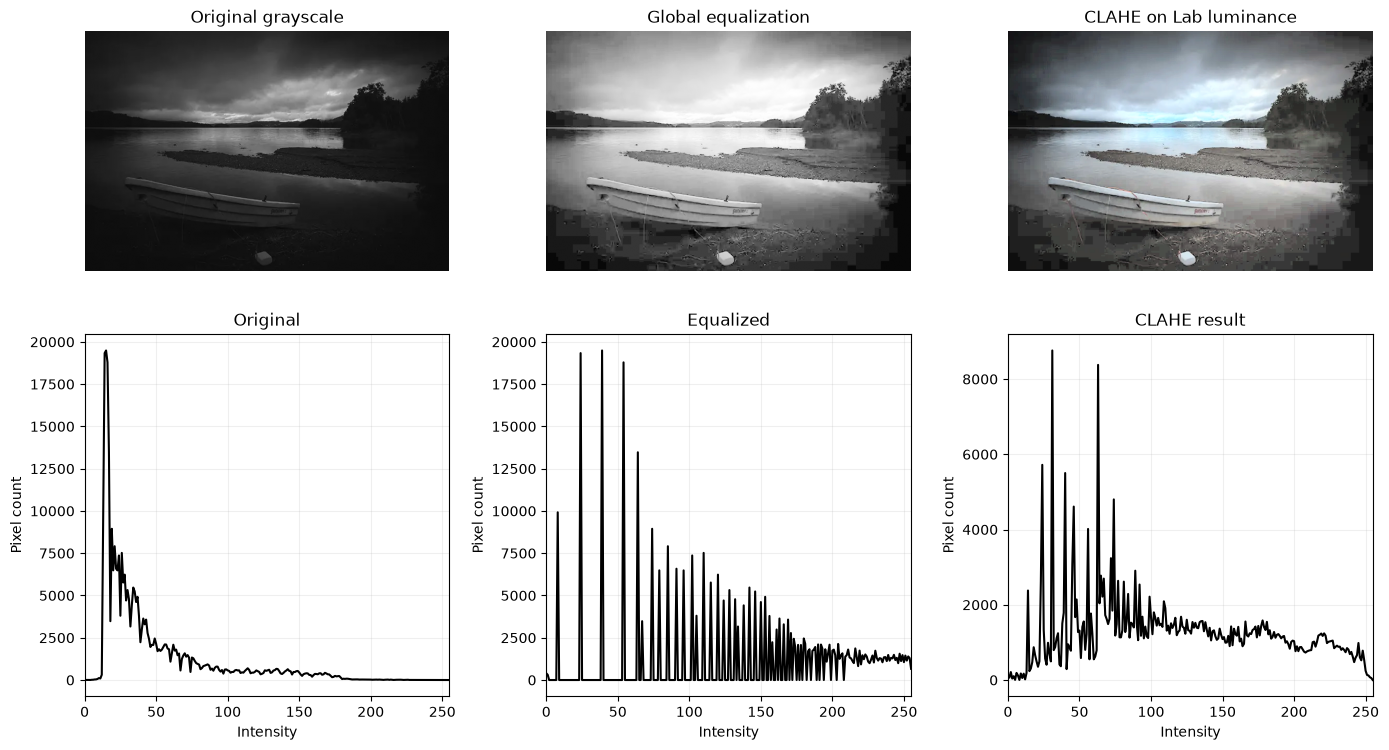

In [ ]:
image_rgb = load_rgb("barco.png")
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray)

lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
L_channel, a_channel, b_channel = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(2, 2 ))
L_clahe = clahe.apply(L_channel)
clahe_rgb = cv2.cvtColor(cv2.merge((L_clahe, a_channel, b_channel)), cv2.COLOR_LAB2RGB)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original grayscale")
axes[0, 1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Global equalization")
axes[0, 2].imshow(clahe_rgb)
axes[0, 2].set_title("CLAHE on Lab luminance")

for axis, image, title in zip(
    axes[1],
    [gray, equalized, cv2.cvtColor(clahe_rgb, cv2.COLOR_RGB2GRAY)],
    ["Original", "Equalized", "CLAHE result"],
):
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()
    axis.plot(histogram, color="black")
    axis.set(title=title, xlabel="Intensity", ylabel="Pixel count", xlim=(0, 255))
    axis.grid(alpha=0.2)
for axis in axes[0]:
    axis.axis("off")
plt.tight_layout()
plt.show()

In [12]:
def summary(image: np.ndarray) -> tuple[float, float, float]:
    return float(image.mean()), float(image.std()), float(np.mean((image == 0) | (image == 255)))

gray_clahe = cv2.cvtColor(clahe_rgb, cv2.COLOR_RGB2GRAY)
for name, image in {"Original": gray, "Equalized": equalized, "CLAHE": gray_clahe}.items():
    mean, std, saturation = summary(image)
    print(f"{name:10s}: mean={mean:7.2f}, std={std:7.2f}, saturation={saturation:.4f}")

SAVE_RESULTS = False
if SAVE_RESULTS:
    cv2.imwrite(str(STUDENT_IMAGES / "unit2_global_equalization.png"), equalized)
    cv2.imwrite(
        str(STUDENT_IMAGES / "unit2_clahe_lab.png"),
        cv2.cvtColor(clahe_rgb, cv2.COLOR_RGB2BGR),
    )
    print(f"Results saved in {STUDENT_IMAGES}")

Original  : mean=  45.49, std=  38.77, saturation=0.0000
Equalized : mean= 130.30, std=  71.33, saturation=0.0033
CLAHE     : mean= 116.17, std=  64.24, saturation=0.0003


## Interpretation

Independent equalization of RGB channels is avoided because it can alter color relationships. CLAHE parameters must be validated: small tiles can create artificial local contrast, and a high clip limit can amplify noise. 